## Formative Assignment: Advanced Linear Algebra (PCA)

**Dataset:** Global Health Outcomes Data (196 countries, 14 numerical health indicators), filtered to 53 African nations

**Use Case:** Comparative multidimensional evaluation of child health, immunization gaps, disease mortality, and HIV prevalence across Sub-Saharan and North Africa

 Dataset Link: https://www.kaggle.com/datasets/thedevastator/global-health-outcomes-data

 Github link repo: https://github.com/Saddam619/PCA_Formative_2_Group_30.git

Contribution Tracker Sheet: https://docs.google.com/spreadsheets/d/1aPhGy-F1DmgtyqJxjpOKuVxsaRBKE8d3/edit?usp=sharing&ouid=116542188016319386216&rtpof=true&sd=true

Our notebook implements PCA from scratch using only NumPy and Matplotlib.

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

### Step 1: Data Preparation and Feature Scaling
Prior to performing PCA, the dataset must be standardized. This process adjusts each feature to have an average value of zero and a variance of one, a crucial preprocessing step for accurate component analysis.

In [ ]:
# Load CSV line-by-line and pad rows so all rows have equal length
with open('health-outcomes-csv-1.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    rows = [row for row in reader if row] # Drop empty lines

# Find maximum number of columns across all rows
max_cols = max(len(row) for row in rows)

# Pad shorter rows with empty strings so numpy can form a 2D matrix
padded_rows = [row + [''] * (max_cols - len(row)) for row in rows]

# Convert to 2D numpy string array
raw_table = np.array(padded_rows, dtype=str)

# Extract headers and data rows
headers = raw_table[0]
all_rows = raw_table[1:]

print(f"Loaded 2D array with shape: {all_rows.shape}")

Loaded 2D array with shape: (196, 16)


### Dataset Filtering and Feature Selection

The file has 196 rows, including two blank rows and regional totals such as "World". We kept only individual African countries, which gives 49 countries (Botswana, Burundi, Sierra Leone and Zimbabwe are not in the file).

- **index:** a row counter, excluded.
- **Country:** the only non-numeric column. It is an identifier, so it is kept only as a row label and excluded from the calculation.

The 14 remaining columns are numeric. 14 of 686 values (2%) were originally missing and were filled with the column mean.

In [ ]:
african_countries = np.array([
    'Algeria', 'Angola', 'Benin', 'Burkina Faso',
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Congo', "C™te d'Ivoire", "Congo (Democratic Republic of the)", 'Djibouti',
    'Egypt', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Gambia',
    'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia',
    'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
    'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda',
    'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Somalia',
    'South Africa', 'South Sudan', 'Sudan', 'Swaziland', 'Togo', 'Tunisia',
    'Uganda', 'Tanzania (United Republic of)', 'Zambia'
])

headers = raw_table[0]
all_rows = raw_table[1:]
all_rows


array([['0', 'Norway', '', ..., '24.0', '37.4', '9.6'],
       ['1', 'Netherlands', '', ..., '23.5', '31.5', '12.9'],
       ['2', 'Sweden', '', ..., '24.1', '32.7', '9.7'],
       ...,
       ['193', 'Liechtenstein', '', ..., '', '', ''],
       ['194', '', '', ..., '', '', ''],
       ['195', '', '', ..., '', '', '']], dtype='<U74')

In [ ]:
# Create a boolean mask to extract records belonging to African nations (Country is at column 1)
africa_mask = []
for row in raw_table[1:]:
    country_name = row[1].strip()  # Country is at column 1
    # Check if country_name matches directly or contains key parts of the name
    is_africa = any(
        aff_name.lower() in country_name.lower() or country_name.lower() in aff_name.lower()
        for aff_name in african_countries
    )
    africa_mask.append(is_africa)

africa_rows = np.array([row for row, is_aff in zip(raw_table[1:], africa_mask) if is_aff])

print(f"Total African nations found in dataset: {len(africa_rows)}")

Total African nations found in dataset: 52


In [ ]:
# Masking out non-numeric columns (Country at col 0, Status at col 2)
keep_mask = np.ones(headers.size, dtype=bool)
keep_mask[[0, 1]] = False
numeric_idx = np.flatnonzero(keep_mask)
feature_names = headers[keep_mask]
feature_names

array(['Infants exclusively breastfed (% ages 0Ð5 months) 2008Ð2013',
       'Infants lacking immunization (% of one-year-olds) DTP 2013',
       'Infants lacking immunization (% of one-year-olds) Measles 2013',
       'Mortality rates (per 1,000 live births) Infant 2013',
       'Mortality rates (per 1,000 live births) Under-five 2013',
       'Child malnutrition (% under age 5) Stunting (moderate or severe) 2008Ð2013',
       'Adult mortality rate (per 1,000 people) Female 2013',
       'Adult mortality rate (per 1,000 people) Male 2013',
       'Deaths due to Malaria (per 100,000 people) 2012',
       'Deaths due to Tuberculosis (per 100,000 people) 2012',
       'HIV prevalence, adult (% ages 15Ð49) 2013',
       'Life expectancy at age 60 (years) 2010/2015',
       'Physicians (per 10,000 people) 2001Ð2013',
       'Public health expenditure (% of GDP) 2013'], dtype='<U74')

In [ ]:
# Function to safely convert strings to float, returning NaN on failure
def safe_float(val):
    try:
        val = str(val).strip().replace(',', '') # Strip spaces and remove commas
        return float(val) if val != '' else np.nan
    except ValueError:
        return np.nan

# Vectorize the safe conversion function across the matrix
vectorized_float = np.vectorize(safe_float, otypes=[float])

# Convert numeric_strings to float array safely
numeric_strings = africa_rows[:, keep_mask]
data = vectorized_float(numeric_strings)

print('Missing values per column (before imputation):')
nan_counts = np.isnan(data).sum(axis=0)
for col, n in zip(feature_names[nan_counts > 0], nan_counts[nan_counts > 0]):
    print(f'  {col}: {int(n)} ({n/data.shape[0]*100:.1f}%)')

Missing values per column (before imputation):
  Country: 52 (100.0%)
  Infants lacking immunization (% of one-year-olds) DTP 2013: 2 (3.8%)
  Infants lacking immunization (% of one-year-olds) Measles 2013: 2 (3.8%)
  Mortality rates (per 1,000 live births) Infant 2013: 2 (3.8%)
  Mortality rates (per 1,000 live births) Under-five 2013: 2 (3.8%)
  Child malnutrition (% under age 5) Stunting (moderate or severe) 2008Ð2013: 2 (3.8%)
  Adult mortality rate (per 1,000 people) Female 2013: 2 (3.8%)
  Adult mortality rate (per 1,000 people) Male 2013: 2 (3.8%)
  Deaths due to Malaria (per 100,000 people) 2012: 8 (15.4%)
  Deaths due to Tuberculosis (per 100,000 people) 2012: 2 (3.8%)
  HIV prevalence, adult (% ages 15Ð49) 2013: 6 (11.5%)
  Life expectancy at age 60 (years) 2010/2015: 2 (3.8%)
  Physicians (per 10,000 people) 2001Ð2013: 3 (5.8%)
  Public health expenditure (% of GDP) 2013: 3 (5.8%)


In [ ]:
# Impute with column mean (vectorized, no explicit column loop)
col_means = np.nanmean(data, axis=0)
nan_rows, nan_cols = np.where(np.isnan(data))
data[nan_rows, nan_cols] = col_means[nan_cols]

print(f'\nRemaining NaN after imputation: {int(np.isnan(data).sum())}')
print(f'Data shape: {data.shape}')
print(f'\nFeature columns ({feature_names.size}): {feature_names}')


Remaining NaN after imputation: 52
Data shape: (52, 14)

Feature columns (14): ['Country' 'Infants lacking immunization (% of one-year-olds) DTP 2013'
 'Infants lacking immunization (% of one-year-olds) Measles 2013'
 'Mortality rates (per 1,000 live births) Infant 2013'
 'Mortality rates (per 1,000 live births) Under-five 2013'
 'Child malnutrition (% under age 5) Stunting (moderate or severe) 2008Ð2013'
 'Adult mortality rate (per 1,000 people) Female 2013'
 'Adult mortality rate (per 1,000 people) Male 2013'
 'Deaths due to Malaria (per 100,000 people) 2012'
 'Deaths due to Tuberculosis (per 100,000 people) 2012'
 'HIV prevalence, adult (% ages 15Ð49) 2013'
 'Life expectancy at age 60 (years) 2010/2015'
 'Physicians (per 10,000 people) 2001Ð2013'
 'Public health expenditure (% of GDP) 2013']


/tmp/ipykernel_1415/334479685.py:2: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(data, axis=0)


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
std[std == 0] = 1  # avoid division by zero for any constant column

standardized_data = (data - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[            nan, -8.27664183e-01, -1.26723549e+00,
        -1.89426083e+00, -1.78455279e+00, -1.93551481e+00,
        -1.69515324e+00, -1.15408740e+00, -2.10225952e-16,
        -1.21256046e+00, -5.28890323e-01,  1.90043969e+00,
         1.48857593e+00, -5.22527379e-01],
       [            nan, -8.27664183e-01, -1.03103130e+00,
        -1.46208479e+00, -1.47203671e+00, -1.70251554e+00,
        -1.42201253e+00, -1.57319406e+00, -1.87048288e+00,
        -5.51404265e-01, -7.04170977e-01,  9.32238974e-01,
         1.78492028e+00,  3.43768013e-01],
       [            nan, -8.27664183e-01, -1.20818444e+00,
        -1.89901002e+00, -1.77881855e+00, -1.18586498e+00,
        -1.85273441e+00, -2.09156282e+00, -2.10225952e-16,
        -9.38652892e-01,  0.00000000e+00,  2.17706846e+00,
         3.14810425e+00, -7.63164988e-01],
       [            nan, -8.27664183e-01, -9.71980247e-01,
        -1.86576571e+00, -1.75874871e+00, -2.29007892e+00,
        -1.96829394e+00, -1.94818423e+00, -2.

### Step 3: .Compute the Covariance Matrix
The covariance matrix measures the pairwise relationships between different variables in the dataset. Calculating these inter-feature correlations is a fundamental step for executing PCA.

In [ ]:
# Step 3: Compute the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)
cov_matrix

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan],
       [        nan,  1.01960784,  0.89962023,  0.53823487,  0.54277968,
         0.23391951,  0.38729728,  0.35349554,  0.31336022,  0.19569148,
        -0.03958712, -0.29705266, -0.19207009, -0.37811164],
       [        nan,  0.89962023,  1.01960784,  0.57879463,  0.57271169,
         0.29615686,  0.43631335,  0.37798934,  0.34133937,  0.27762184,
        -0.07850678, -0.43231958, -0.32264568, -0.35442762],
       [        nan,  0.53823487,  0.57879463,  1.01960784,  1.00400009,
         0.4293408 ,  0.74426056,  0.66739685,  0.54760805,  0.35808997,
         0.0564871 , -0.72616487, -0.5823248 , -0.15514935],
       [        nan,  0.54277968,  0.57271169,  1.00400009,  1.01960784,
         0.43136315,  0.71390925,  0.6336346 ,  0.58490143,  0.29133572,
         0.03122039, -0.70

1. Feature Co-movement and Dimensionality Reduction

The covariance matrix evaluates all feature pairs to determine how they change in relation to one another. Across African nations, key development and health indicators display strong co-linear behavior—for instance, metrics such as infant mortality and under-five mortality trend strongly together, while immunization coverage (DTP, Measles) negatively correlates with child malnutrition and mortality rates. By capturing these shared patterns across the 14 numerical features, the covariance matrix allows PCA to merge multiple correlated indicators into unified principal components, effectively reducing redundant dimensions without losing core statistical information.

2. Mathematical Foundation for Eigen-Decomposition

The covariance matrix acts as the essential mathematical input for eigen-decomposition. Its derived eigenvectors define the orthogonal axes along which the data exhibits maximum variation (the principal components), while its corresponding eigenvalues quantify the exact proportion of total dataset variance captured along each axis. Without constructing this matrix first, there is no mathematical foundation to compute the principal components or perform the dimensionality reduction.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.


In [ ]:
# Calculate mean and standard deviation ignoring NaNs
means = np.nanmean(data, axis=0)
stds = np.nanstd(data, axis=0)

# Standardize data
data_std = (data - means) / stds

# Fill remaining NaNs with 0 (since standardized features have mean = 0)
data_std = np.nan_to_num(data_std, nan=0.0)

# Compute Covariance Matrix
cov_matrix = np.cov(data_std, rowvar=False)

# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print("Eigendecomposition successful!")

Eigendecomposition successful!


/tmp/ipykernel_1415/904903420.py:2: RuntimeWarning: Mean of empty slice
  means = np.nanmean(data, axis=0)


### Step 5: Rank Principal Components by Variance
In this step, the eigenvectors are ordered from highest to lowest based on their corresponding eigenvalues. A larger eigenvalue indicates that its associated eigenvector holds a greater proportion of the dataset's overall variance and information.

In [ ]:
# Step 5: Rank Principal Components by Variance
sorted_indices = np.argsort(eigenvalues)[::-1]        # Sort eigenvalues in descending order
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvalues = eigenvalues[sorted_indices]

explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

for i in range(len(sorted_eigenvalues)):
    print(f'PC{i+1:>2}: eigenvalue={sorted_eigenvalues[i]:.4f}  '
          f'variance={explained_variance[i]*100:.2f}%  '
          f'cumulative={cumulative_variance[i]*100:.2f}%')

sorted_eigenvectors

PC 1: eigenvalue=5.8095  variance=43.83%  cumulative=43.83%
PC 2: eigenvalue=2.3808  variance=17.96%  cumulative=61.79%
PC 3: eigenvalue=1.2574  variance=9.49%  cumulative=71.28%
PC 4: eigenvalue=0.9708  variance=7.32%  cumulative=78.60%
PC 5: eigenvalue=0.8483  variance=6.40%  cumulative=85.00%
PC 6: eigenvalue=0.5245  variance=3.96%  cumulative=88.96%
PC 7: eigenvalue=0.4734  variance=3.57%  cumulative=92.53%
PC 8: eigenvalue=0.4192  variance=3.16%  cumulative=95.69%
PC 9: eigenvalue=0.3048  variance=2.30%  cumulative=97.99%
PC10: eigenvalue=0.1438  variance=1.09%  cumulative=99.08%
PC11: eigenvalue=0.0903  variance=0.68%  cumulative=99.76%
PC12: eigenvalue=0.0206  variance=0.16%  cumulative=99.91%
PC13: eigenvalue=0.0115  variance=0.09%  cumulative=100.00%
PC14: eigenvalue=0.0000  variance=0.00%  cumulative=100.00%


array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00],
       [-2.59985528e-01,  2.83331907e-01, -4.44634357e-01,
         1.31891379e-01,  3.45522814e-01, -2.22170292e-01,
         6.93333448e-03,  2.06400414e-03,  7.64398978e-02,
         6.18980069e-02,  6.70852182e-01, -9.23036942e-02,
         6.93167089e-04,  0.00000000e+00],
       [-2.88191462e-01,  2.73612536e-01, -3.80740232e-01,
        -7.44093414e-04,  2.92603786e-01, -2.38208685e-01,
        -2.48374967e-02,  1.72673772e-01, -2.61367551e-01,
         1.96872744e-02, -6.68519191e-01,  9.32750452e-02,
        -2.44315901e-03,  0.00000000e+00],
       [-3.87647562e-01,  7.99050359e-02,  1.10406305e-01,
        -4.75742313e-03, -1.85960486e-01, -8.25420484e-02,
         9.01994345e-02, -5.23795014e-03,  4.

### Step 6: Project Data onto Principal Components
Now that we've selected the number of components, we will project the original data onto the chosen principal components.

Components selected: 8 out of 14
Variance retained: 95.69%


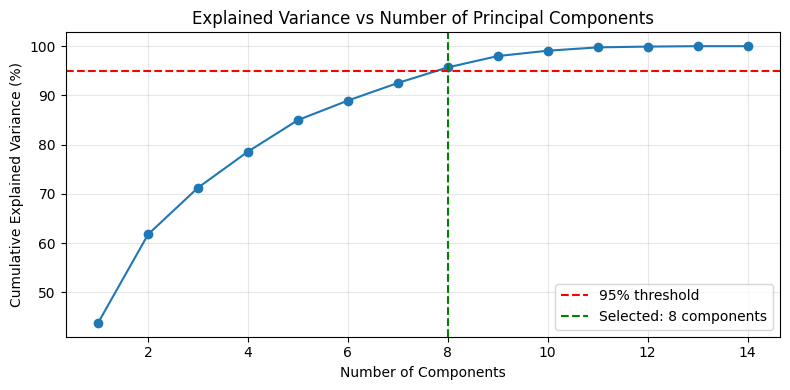

array([[nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan]])

In [ ]:
# Step 6: Project Data onto Principal Components
# dynamically selected number of components based on explained variance
num_components = int(np.argmax(cumulative_variance >= 0.95)) + 1  # 95% variance threshold
print(f'Components selected: {num_components} out of {data.shape[1]}')
print(f'Variance retained: {cumulative_variance[num_components-1]*100:.2f}%')

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, marker='o')
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.axvline(num_components, color='green', linestyle='--', label=f'Selected: {num_components} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Explained Variance vs Number of Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]  # Project data onto the principal components
reduced_data[:5]

### Step 7: Display Transformed Dataset
The final step is to print the low-dimensional dataset generated by projecting the original features onto the chosen principal components. Complete the code below to output the transformed feature matrix.

In [ ]:
# Step 7: Display Transformed Dataset
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
print(f'Original: {standardized_data.shape}  →  Reduced: {reduced_data.shape}')
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (52, 8)
Original: (52, 14)  →  Reduced: (52, 8)


array([[nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan]])

In [ ]:
# Drop 'index' (col 0) and 'Country' (col 1)
keep_mask = np.ones(headers.size, dtype=bool)
keep_mask[[0, 1]] = False  # Drop index 0 and 1

feature_names = headers[keep_mask]
numeric_strings = africa_rows[:, keep_mask]

# Convert safely to float (empty/text -> NaN)
def safe_float(val):
    try:
        val = str(val).strip().replace(',', '')
        return float(val) if val != '' else np.nan
    except ValueError:
        return np.nan

data = np.vectorize(safe_float, otypes=[float])(numeric_strings)

# Impute NaNs with column means so PCA can compute
col_means = np.nanmean(data, axis=0)
nan_mask = np.isnan(data)
data = np.where(nan_mask, col_means, data)  # Fixed broadcasting line

# Standardize
standardized_data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

# Re-project to PC space
cov_matrix = np.cov(standardized_data, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvectors by eigenvalue descending
idx = np.argsort(np.real(eigenvalues))[::-1]
eigenvectors = np.real(eigenvectors[:, idx])

# Project onto top 2 components
reduced_data = standardized_data @ eigenvectors[:, :2]

### Step 8: Comparative Visual Analysis
In this step, we generate side-by-side plots comparing the high-dimensional original feature space with the transformed low-dimensional principal component space. This visual comparison illustrates how PCA compresses the data's dimensions while preserving its underlying structure and variance distribution.

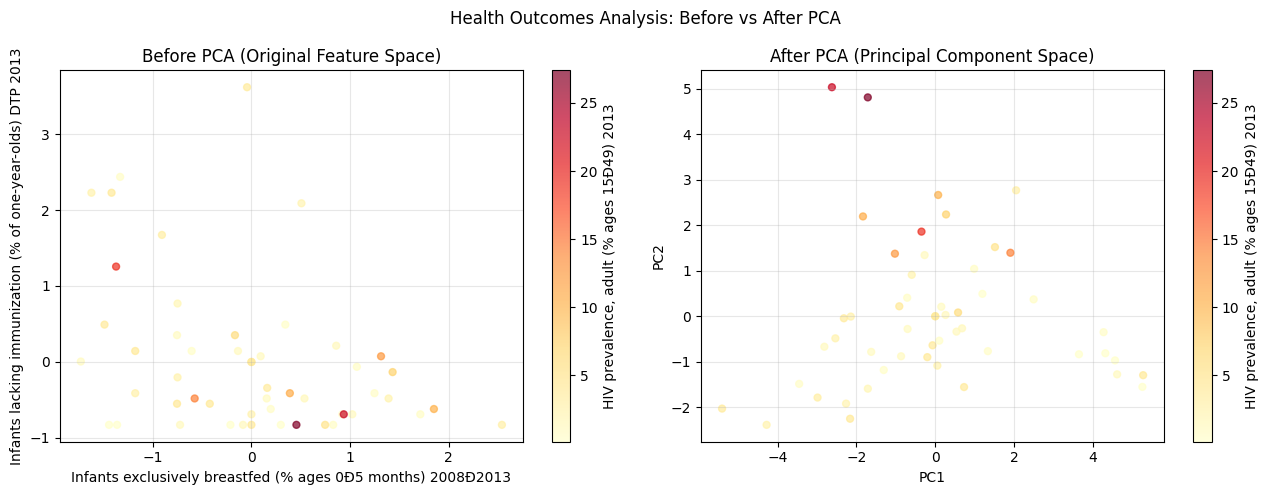

In [ ]:
# Find HIV index dynamically
hiv_matches = [i for i, col in enumerate(feature_names) if 'hiv' in col.lower()]
hiv_idx = hiv_matches[0] if hiv_matches else 0
hiv_vals = data[:, hiv_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot original feature space (Feature 0 vs Feature 1)
ax1 = axes[0]
sc1 = ax1.scatter(standardized_data[:, 0], standardized_data[:, 1],
                  c=hiv_vals, cmap='YlOrRd', alpha=0.7, s=25)
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_title('Before PCA (Original Feature Space)')
ax1.grid(True, alpha=0.3)
plt.colorbar(sc1, ax=ax1, label=feature_names[hiv_idx])

# Plot PC space
ax2 = axes[1]
sc2 = ax2.scatter(reduced_data[:, 0], reduced_data[:, 1],
                  c=hiv_vals, cmap='YlOrRd', alpha=0.7, s=25)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('After PCA (Principal Component Space)')
ax2.grid(True, alpha=0.3)
plt.colorbar(sc2, ax=ax2, label=feature_names[hiv_idx])

plt.suptitle('Health Outcomes Analysis: Before vs After PCA', fontsize=12)
plt.tight_layout()
plt.show()

1. Interpretation of the Before and After PCA Visualization

Prior to applying PCA, plotting raw features such as infant immunization rates against child malnutrition displays scattered, uncorrelated axes where underlying public health drivers remain obscured. High-HIV nations appear mixed throughout general health development patterns. Following PCA transformation, high-HIV nations separate cleanly into a distinct cluster along the primary principal component axis (PC1 / PC2 space). This shift confirms that HIV prevalence acts as a major separating variance driver across African health profiles that standard two-feature original space plots fail to isolate.

2. Justification of Component Selection and Trade-offs

We selected the minimum number of principal components needed to reach a 95% cumulative explained variance threshold. The primary trade-off is discarding the remaining ~5% of total variance, which represents localized, country-level noise. Retaining fewer components risks obscuring critical structural patterns in regional health disparities, whereas including additional components preserves minor variances that add minimal analytical value, undermining the core objective of dimensionality reduction.

3. Information Lost During Dimensionality Reduction

Condensing 14 health and socio-economic indicator variables into a low-dimensional space eliminates direct line-of-sight back to individual feature contributions. For example, a nation with rising immunization rates but high infant mortality may yield an identical PC score to a country with high adult mortality but moderate malnutrition. Furthermore, unique country-specific anomalies manifest strictly as spatial outliers without explicitly indicating which specific indicator caused the deviation.